In [45]:
import pandas as pd
import numpy as np

In [46]:
df=pd.read_csv("../data/raw/city_day.csv")

In [47]:
df_clean = df.copy()

In [48]:
#Check Missing Percentages
missing_percentage = (df_clean.isnull().sum()/len(df_clean))*100

missing_df = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


In [50]:
#Drop Xylene


df_clean.drop(columns=["Xylene"], inplace=True)

In [51]:
#Remove rows missing the target AQI
df_clean.dropna(subset=["AQI"], inplace=True)

In [52]:
df_clean.shape

(24850, 15)

In [53]:
df_clean.isnull().sum()

City             0
Date             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
AQI              0
AQI_Bucket       0
dtype: int64

<Axes: >

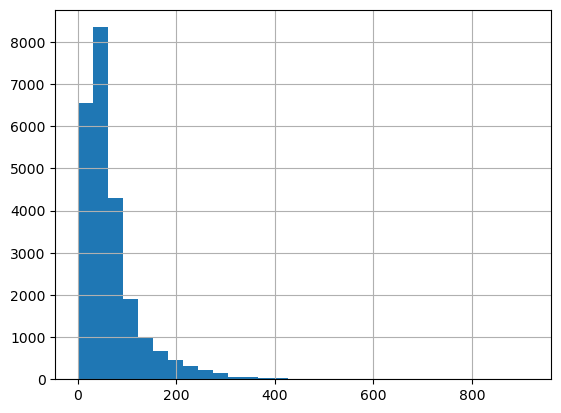

In [54]:
df_clean["PM2.5"].hist(bins=30)

<Axes: >

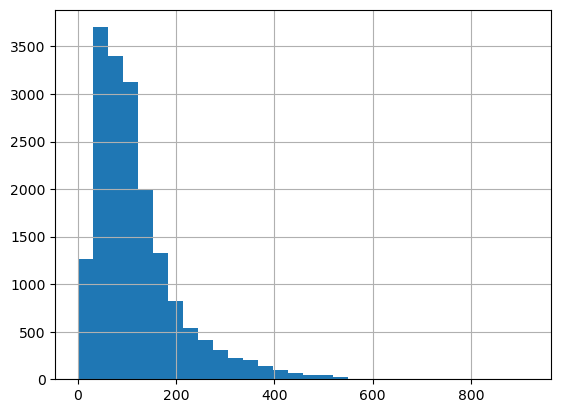

In [33]:
df_clean["PM10"].hist(bins=30)

<Axes: >

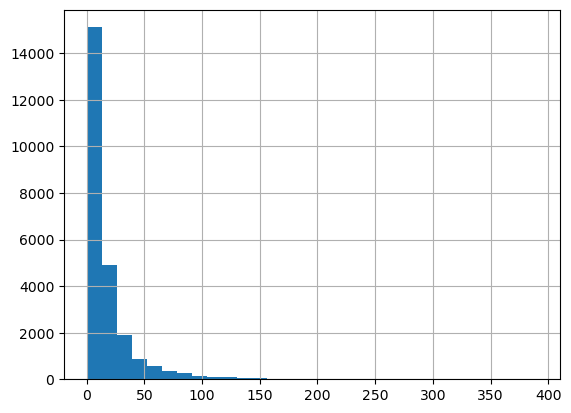

In [34]:
df_clean["NO"].hist(bins=30)

<Axes: >

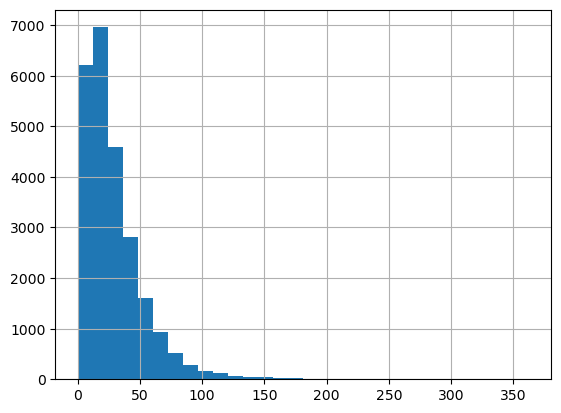

In [35]:
df_clean["NO2"].hist(bins=30)

<Axes: >

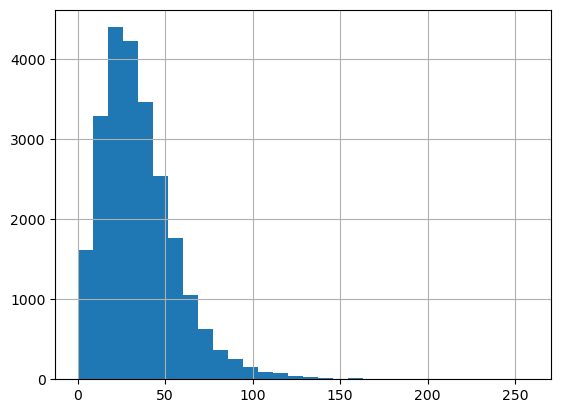

In [36]:
df_clean["O3"].hist(bins=30)

<Axes: >

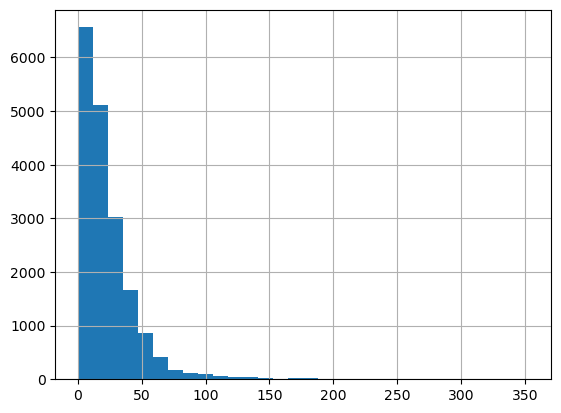

In [37]:
df_clean["NH3"].hist(bins=30)

<Axes: >

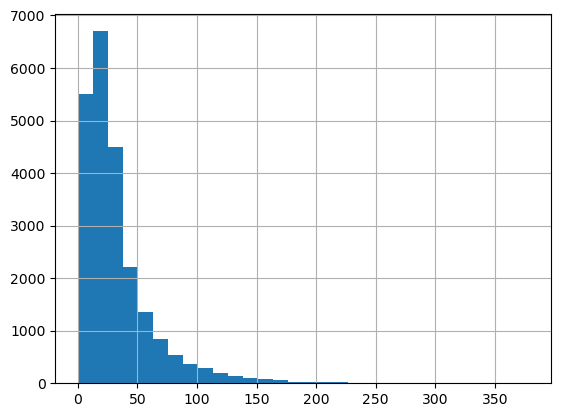

In [38]:
df_clean["NOx"].hist(bins=30)

<Axes: >

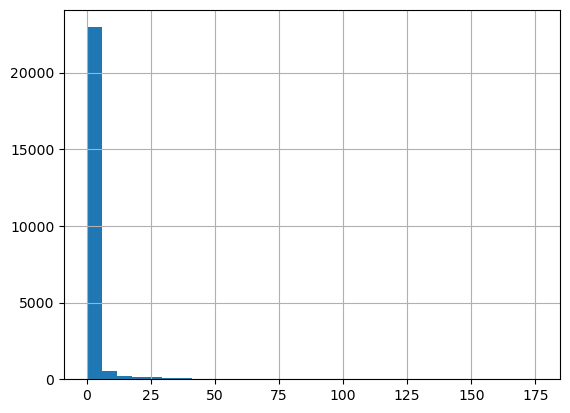

In [39]:
df_clean["CO"].hist(bins=30)

<Axes: >

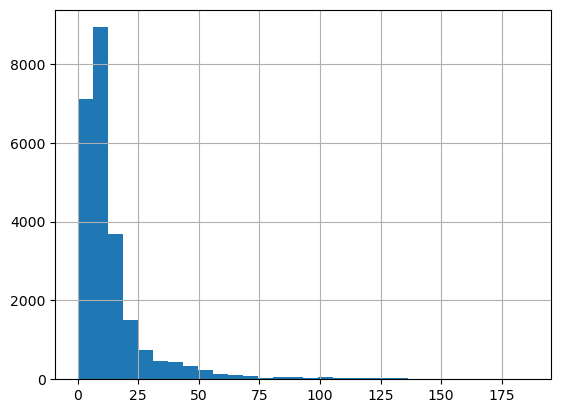

In [40]:
df_clean["SO2"].hist(bins=30)

<Axes: >

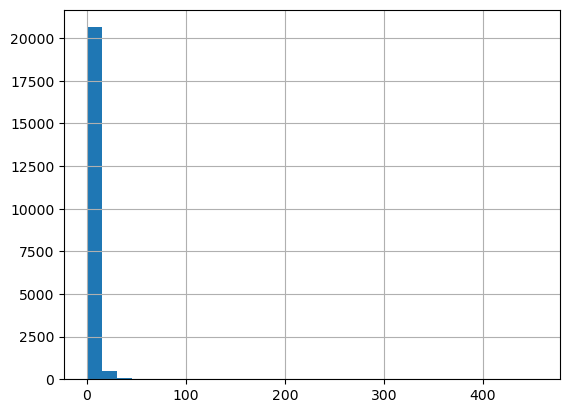

In [41]:
df_clean["Benzene"].hist(bins=30)

<Axes: >

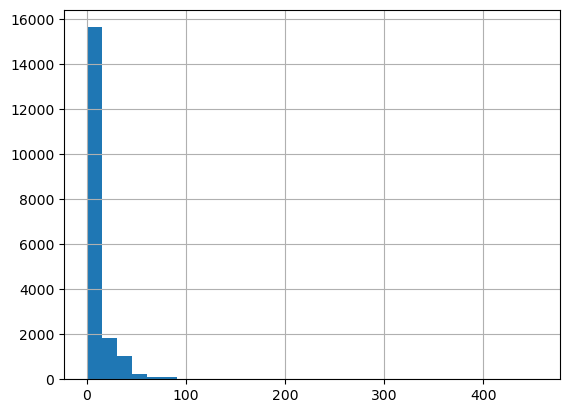

In [42]:
df_clean["Toluene"].hist(bins=30)

In [55]:
numerical_cols = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]
for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [56]:
df_clean.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [57]:
df_clean.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [61]:
df_clean[df_clean.isna().any(axis=1)].shape

(0, 15)

In [62]:
#Dataset Shape
print("Dataset Shape:", df_clean.shape)

Dataset Shape: (24850, 15)


In [63]:
#Dataset Missing Values
print("\nMissing Values:")
print(df_clean.isnull().sum())


Missing Values:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


In [64]:
#Duplicates Rows
print("\nDuplicate Rows:", df_clean.duplicated().sum())


Duplicate Rows: 0


In [65]:
#Data Types
print("\nData Types:")
print(df_clean.dtypes)


Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
AQI           float64
AQI_Bucket     object
dtype: object


In [67]:
df_clean.to_csv("../data/processed/clean_air_quality.csv", index=False)